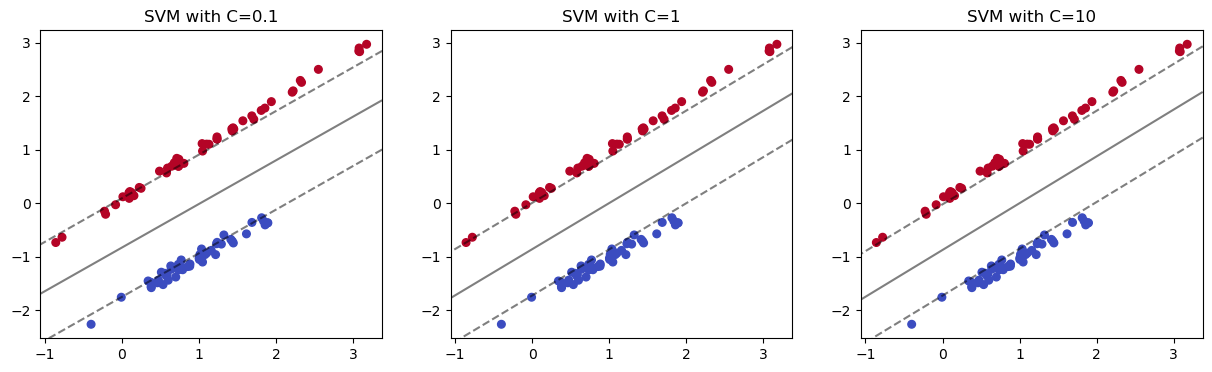

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.svm import SVC

# 1. Create a toy dataset (not perfectly separable)
X, y = datasets.make_classification(
    n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, n_samples=100, random_state=42
)

# 2. Try different values of C
C_values = [0.1, 1, 10]

plt.figure(figsize=(15, 4))

for i, C in enumerate(C_values, 1):
    clf = SVC(kernel="linear", C=C)
    clf.fit(X, y)

    # Plot decision boundary
    plt.subplot(1, 3, i)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=30)
    
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Create grid
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)

    # Plot decision boundary and margins
    ax.contour(XX, YY, Z, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    
    plt.title(f"SVM with C={C}")

plt.show()